 6. In this exercise, you will further analyze the Wage data set considered throughout this chapter.

(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.


CV mean MSE by degree:
 degree 1: MSE=1677.205
 degree 2: MSE=1601.356
 degree 3: MSE=1596.246
 degree 4: MSE=1595.074
 degree 5: MSE=1595.071
 degree 6: MSE=1594.868
 degree 7: MSE=1593.864
 degree 8: MSE=1593.449
 degree 9: MSE=1596.119
 degree 10: MSE=1603.719

Best degree by CV: 8

ANOVA p-values comparing degree d vs d+1:
1 vs 2: p = 3.077e-32
2 vs 3: p = 0.001687
3 vs 4: p = 0.05104
4 vs 5: p = 0.3697
5 vs 6: p = 0.1162
6 vs 7: p = nan
7 vs 8: p = nan
8 vs 9: p = nan
9 vs 10: p = nan

ANOVA suggests degree (based on sequential tests): 3


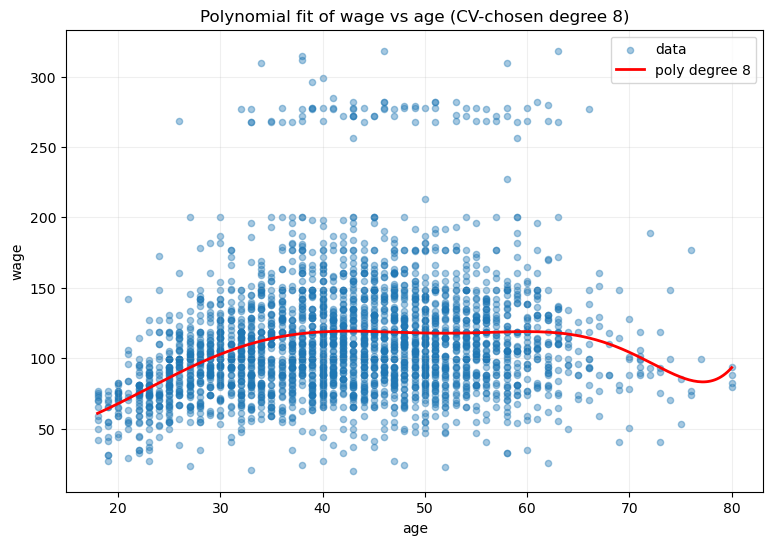

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv('Wage.csv')

# Keep only the columns we need and drop NA rows
df = df[['age', 'wage']].dropna().copy()
X = df[['age']].values
y = df['wage'].values

# Cross-validation to choose polynomial degree
degrees = list(range(1, 11))
cv = KFold(n_splits=10, shuffle=True, random_state=1)
mse_cv = []
for d in degrees:
    pf = PolynomialFeatures(d, include_bias=False)
    Xp = pf.fit_transform(X)
    lr = LinearRegression()
    scores = cross_val_score(lr, Xp, y, scoring='neg_mean_squared_error', cv=cv)
    mse_cv.append(-scores.mean())

best_degree = degrees[int(np.argmin(mse_cv))]
print('\nCV mean MSE by degree:')
for d, m in zip(degrees, mse_cv):
    print(f' degree {d}: MSE={m:.3f}')
print('\nBest degree by CV:', best_degree)

# ANOVA: fit nested polynomial models using statsmodels and compare sequentially
models = {}
for d in degrees:
    pf = PolynomialFeatures(d, include_bias=False)
    Xp = pf.fit_transform(df[['age']])
    cols = [f'age_pow_{i+1}' for i in range(Xp.shape[1])]
    Xp_df = pd.DataFrame(Xp, columns=cols)
    model_df = pd.concat([df['wage'].reset_index(drop=True), Xp_df.reset_index(drop=True)], axis=1)
    formula = 'wage ~ ' + ' + '.join(cols)
    models[d] = ols(formula, data=model_df).fit()

anova_results = []
for d in range(1, max(degrees)):
    try:
        an = sm.stats.anova_lm(models[d], models[d+1])
        pval = an['Pr(>F)'].iloc[1]
    except Exception as e:
        pval = np.nan
    anova_results.append((d, d+1, pval))

print('\nANOVA p-values comparing degree d vs d+1:')
for a in anova_results:
    print(f'{a[0]} vs {a[1]}: p = {a[2]:.4g}')

# Determine degree suggested by ANOVA: pick largest d where improvement was significant
sig_degree = 1
for d, d1, p in anova_results:
    if not np.isnan(p) and p < 0.05:
        sig_degree = d1
print('\nANOVA suggests degree (based on sequential tests):', sig_degree)

# Fit final model using CV-chosen degree and plot the fit
pf = PolynomialFeatures(best_degree, include_bias=False)
Xp = pf.fit_transform(X)
lr = LinearRegression().fit(Xp, y)
age_grid = np.linspace(df['age'].min(), df['age'].max(), 300).reshape(-1,1)
pred = lr.predict(pf.transform(age_grid))

plt.figure(figsize=(9,6))
plt.scatter(df['age'], df['wage'], alpha=0.4, s=20, label='data')
plt.plot(age_grid, pred, color='red', lw=2, label=f'poly degree {best_degree}')
plt.xlabel('age')
plt.ylabel('wage')
plt.title(f'Polynomial fit of wage vs age (CV-chosen degree {best_degree})')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

(b) Fit a step function to predict wage using age, and perform cross validation to choose the optimal number of cuts. Make a plot of the fit obtained.


CV mean MSE by number of cuts:
 cuts=2: MSE=1735.450
 cuts=3: MSE=1683.428
 cuts=4: MSE=1636.632
 cuts=5: MSE=1631.093
 cuts=6: MSE=1624.148
 cuts=7: MSE=1612.767
 cuts=8: MSE=1602.331
 cuts=9: MSE=1610.919
 cuts=10: MSE=1607.119

Best number of cuts by CV: 8


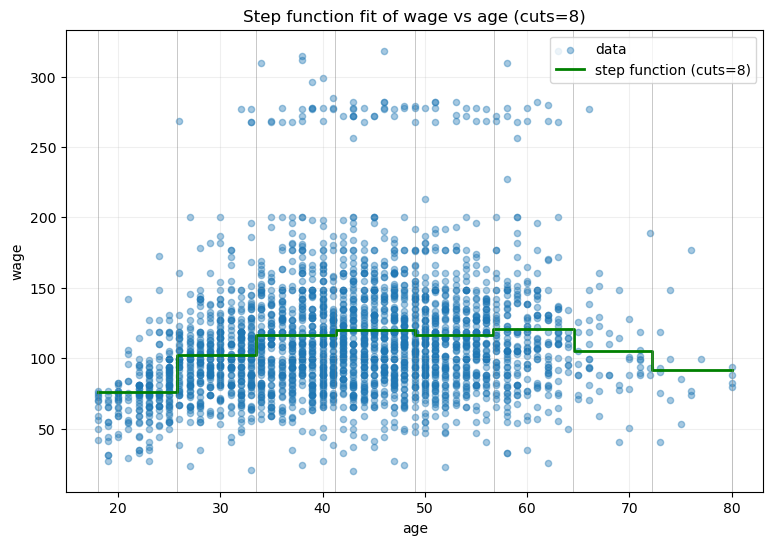

In [3]:
# (b) Step function: choose number of cuts by CV and plot the fit
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt

# We'll try different numbers of cuts (bins) and use 10-fold CV to choose the best
ks = list(range(2, 11))  # number of bins/cuts to try
cv = KFold(n_splits=10, shuffle=True, random_state=1)
mse_k = []
# use consistent bins based on age range for each k (equal-width)
age_min, age_max = df['age'].min(), df['age'].max()
for k in ks:
    bins = np.linspace(age_min, age_max, k + 1)
    cat = pd.cut(df['age'], bins=bins, include_lowest=True)
    X_step = pd.get_dummies(cat)
    lr = LinearRegression()
    scores = cross_val_score(lr, X_step, y, scoring='neg_mean_squared_error', cv=cv)
    mse_k.append(-scores.mean())

best_k = ks[int(np.argmin(mse_k))]
print('\nCV mean MSE by number of cuts:')
for k, m in zip(ks, mse_k):
    print(f' cuts={k}: MSE={m:.3f}')
print('\nBest number of cuts by CV:', best_k)

# Fit final step-function model with best_k on the full data
bins = np.linspace(age_min, age_max, best_k + 1)
cat_full = pd.cut(df['age'], bins=bins, include_lowest=True)
X_step_full = pd.get_dummies(cat_full)
lr_final = LinearRegression().fit(X_step_full, y)

# Predict on a fine age grid (make sure dummy columns align)
age_grid = np.linspace(age_min, age_max, 300)
cat_grid = pd.cut(age_grid, bins=bins, include_lowest=True)
X_grid = pd.get_dummies(cat_grid)
# Align columns (in case some bins are empty in data)
X_grid = X_grid.reindex(columns=X_step_full.columns, fill_value=0)
pred_grid = lr_final.predict(X_grid.values)

# Plot data and step-function fit
plt.figure(figsize=(9,6))
plt.scatter(df['age'], df['wage'], alpha=0.4, s=20, label='data')
# draw step function using step plot
plt.step(age_grid, pred_grid, where='mid', color='green', lw=2, label=f'step function (cuts={best_k})')
# show bin edges
for edge in bins:
    plt.axvline(edge, color='gray', lw=0.5, alpha=0.6)
plt.xlabel('age')
plt.ylabel('wage')
plt.title(f'Step function fit of wage vs age (cuts={best_k})')
plt.legend()
plt.grid(alpha=0.2)
plt.show()